# Część V — Statystyka w PID

- modele wiarygodności (likelihood) dla dwóch hipotez,
- posterior Bayesowski i iloraz wiarygodności,
- klasyfikator: macierz pomyłek, efficiency, purity, odrzut tła,
- krzywe ROC i AUC,
- próg pod cel analizy (w tym orientacyjne miary istotności i Asimov \(Z_A\)),
- niepewności statystyczne i systematyczne (bootstrap + przykład przesunięcia kalibracji),
- szacowanie piku w masie niezmienniczej i typowe metody tła (fit, sideband, mixed events, like-sign).

## Wymagania
`numpy`, `matplotlib`, `scipy`, `pandas`, `scikit-learn`.


In [ ]:
# Colab / świeże środowisko: doinstaluj zależności
# (w Colab zwykle już są, ale to zapewnia powtarzalność)

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    %pip -q install numpy matplotlib scipy scikit-learn pandas

# Ustawienia wykresów
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.grid"] = True

print("Running in Colab" if IN_COLAB else "Running locally")

In [2]:
from dataclasses import dataclass

from scipy.stats import norm
from scipy.optimize import curve_fit

from sklearn.metrics import roc_curve, auc, confusion_matrix

## 1) Dane: dwie hipotezy i wektor cech

W slajdach oznaczaliśmy pomiary jako \(\vec{x}\). Dla ćwiczeń zrobimy prosty przypadek binarny:

- **S**: „sygnał” (np. \(K\))
- **B**: „tło” (np. \(\pi\))

Zbudujemy dwa pomiary/cechy:
- \(x_1\): analog \(\Delta\ln\mathcal{L}\) (ciągła zmienna rozdzielająca),
- \(x_2\): dodatkowa cecha (słabsza, ale pomocna).


In [3]:
N_S = 4000
N_B = 8000

# Prawdziwe parametry rozkładu dla x1 (do późniejszego porównania z fitami)
TRUE_MU_S_X1, TRUE_SIG_S_X1 = 1.2, 1.0
TRUE_MU_B_X1, TRUE_SIG_B_X1 = 0.0, 1.0

x1_S = np.random.normal(loc=TRUE_MU_S_X1, scale=TRUE_SIG_S_X1, size=N_S)
x1_B = np.random.normal(loc=TRUE_MU_B_X1, scale=TRUE_SIG_B_X1, size=N_B)

# Druga cecha: słabsza separacja
x2_S = np.random.normal(loc=0.6, scale=1.2, size=N_S)
x2_B = np.random.normal(loc=0.0, scale=1.2, size=N_B)

sum1 = np.concatenate([x1_S, x1_B])
sum2 = np.concatenate([x2_S, x2_B])

X_S = np.column_stack([x1_S, x2_S])
X_B = np.column_stack([x1_B, x2_B])

X = np.vstack([X_S, X_B])
y = np.hstack([np.ones(N_S, dtype=int), np.zeros(N_B, dtype=int)])  # 1=S, 0=B

X.shape, y.shape

((12000, 2), (12000,))

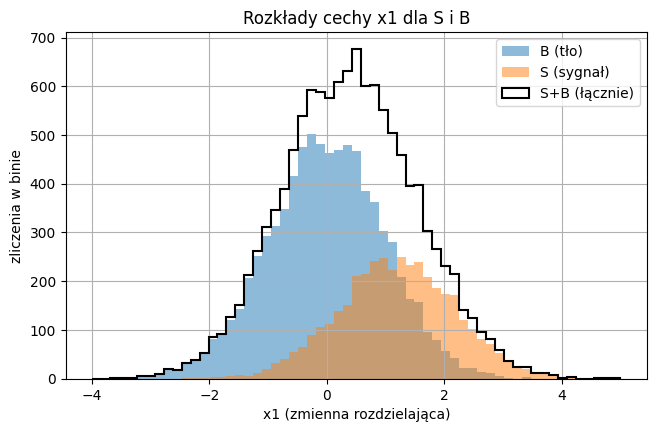

In [4]:
bins = np.linspace(-4, 5, 60)

plt.hist(x1_B, bins=bins, density=False, alpha=0.5, label="B (tło)")
plt.hist(x1_S, bins=bins, density=False, alpha=0.5, label="S (sygnał)")
plt.hist(
    sum1,
    bins=bins,
    density=False,
    histtype="step",
    linestyle="-",
    color="black",
    linewidth=1.5,
    label="S+B (łącznie)",
)
plt.xlabel("x1 (zmienna rozdzielająca)")
plt.ylabel("zliczenia w binie")
plt.title("Rozkłady cechy x1 dla S i B")
plt.legend()
plt.show()

## 2) Likelihood, iloraz wiarygodności i Bayes

Załóżmy prosty model: \(x_1\) jest normalny dla S i B.


a) Estymujemy parametry \((\mu,\sigma)\) osobno dla S i B.

b) Liczymy \(\mathcal{L}_S(x)\) i \(\mathcal{L}_B(x)\), potem \(\Delta\ln\mathcal{L}=\ln\mathcal{L}_S-\ln\mathcal{L}_B\).

c) Dodajemy prior \(P(S)\) i liczymy posterior \(P(S\mid x)\).


In [5]:
@dataclass
class GaussianModel:
    mu: float
    sigma: float

    def pdf(self, x):
        return norm.pdf(x, loc=self.mu, scale=self.sigma)


def fit_gaussian(x):
    return GaussianModel(mu=float(np.mean(x)), sigma=float(np.std(x, ddof=1)))

model_S = fit_gaussian(x1_S)
model_B = fit_gaussian(x1_B)
model_S, model_B

(GaussianModel(mu=1.1826032497559973, sigma=0.9902307850646496),
 GaussianModel(mu=-0.006292764248039987, sigma=0.9875239807828986))

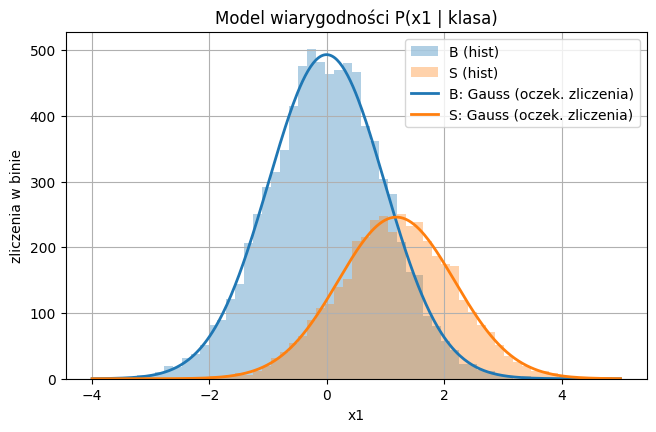

In [6]:
x_grid = np.linspace(-4, 5, 400)
bin_width = float(bins[1] - bins[0])

plt.hist(x1_B, bins=bins, density=False, alpha=0.35, label="B (hist)")
plt.hist(x1_S, bins=bins, density=False, alpha=0.35, label="S (hist)")
plt.plot(
    x_grid,
    N_B * bin_width * model_B.pdf(x_grid),
    color="C0",
    lw=2,
    label="B: Gauss (oczek. zliczenia)",
)
plt.plot(
    x_grid,
    N_S * bin_width * model_S.pdf(x_grid),
    color="C1",
    lw=2,
    label="S: Gauss (oczek. zliczenia)",
)
plt.xlabel("x1")
plt.ylabel("zliczenia w binie")
plt.title("Model wiarygodności P(x1 | klasa)")
plt.legend()
plt.show()

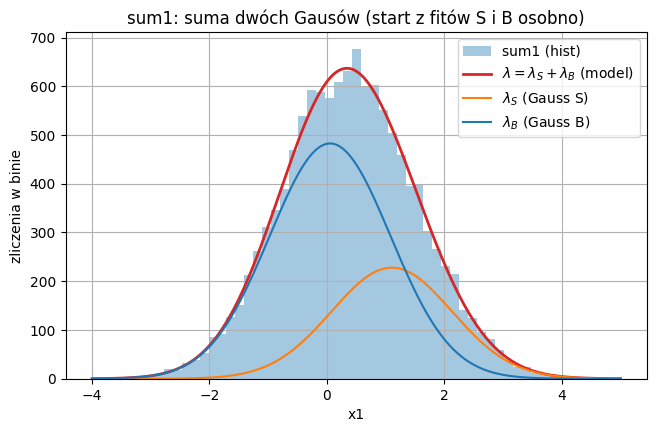

Start [f, μ_S, σ_S, μ_B, σ_B]: [ 0.33333333  1.18260325  0.99023079 -0.00629276  0.98752398]
Po fit: [0.31965829 1.10455402 1.02429257 0.05408072 1.02940208] | minimize OK: True
Prawda: N_S=4000, N_B=8000  |  fit: As≈3836, Ab≈8164

--- Porównanie z parametrami generatora (x1) ---
Model fitu: f*G_S + (1-f)*G_B na sum1 (1. składowa = S, 2. = B).
                                μ          σ     liczność
S generator                 1.200      1.000         4000
S po fit (skł. 1)         1.10455    1.02429       3835.9
B generator                 0.000      1.000         8000
B po fit (skł. 2)         0.05408    1.02940       8164.1

Różnice (fit − prawda):
  Δμ_S = -0.09545,  Δσ_S = +0.02429,  ΔN_S ≈ -164.1
  Δμ_B = +0.05408,  Δσ_B = +0.02940,  ΔN_B ≈ +164.1


In [7]:
# sum1 — dopasowanie jako suma dwóch Gausów na zliczeniach w binach.
# Wiążemy As + Ab = Ntot = len(sum1), więc As = f·Ntot, Ab = (1−f)·Ntot (model mieszaniny).
# Start: f = N_S/Ntot oraz (μ,σ) z osobnych fit_gaussian dla S i B.
# Dopasowanie: maksymalizacja log-wiarygodności Poissona na binach (−∑ log PMF), nie LS na „gęstości”.

from scipy.stats import poisson
from scipy.optimize import minimize

Ntot = len(sum1)
counts_sum, edges = np.histogram(sum1, bins=bins)
ctrs = 0.5 * (edges[:-1] + edges[1:])
bw = float(edges[1] - edges[0])


def two_gauss_bin_counts(x, f, mus, ss, mub, sb):
    return bw * Ntot * (
        f * norm.pdf(x, loc=mus, scale=ss)
        + (1.0 - f) * norm.pdf(x, loc=mub, scale=sb)
    )


def neg_log_lik_bins(p):
    logit_f, mus, ls, mub, lb = p
    f = 1.0 / (1.0 + np.exp(-logit_f))
    ss, sb = np.exp(ls), np.exp(lb)
    lam = two_gauss_bin_counts(ctrs, f, mus, ss, mub, sb)
    lam = np.clip(lam, 1e-12, None)
    return -float(np.sum(poisson.logpmf(counts_sum, lam)))


f0 = N_S / Ntot
p0_two = np.array(
    [
        np.log(f0 / (1.0 - f0)),
        model_S.mu,
        np.log(model_S.sigma),
        model_B.mu,
        np.log(model_B.sigma),
    ],
    dtype=float,
)
res_two = minimize(neg_log_lik_bins, p0_two, method="Powell", options={"maxiter": 20_000})
logit_f, mus_hat, ls_hat, mub_hat, lb_hat = res_two.x
f_hat = 1.0 / (1.0 + np.exp(-logit_f))
ss_hat, sb_hat = np.exp(ls_hat), np.exp(lb_hat)
As_hat, Ab_hat = f_hat * Ntot, (1.0 - f_hat) * Ntot
pars_two = np.array([f_hat, mus_hat, ss_hat, mub_hat, sb_hat])

# Kontrola: na środkach binów λ = λ_S + λ_B (to samo co w log-wiarygodności Poissona)
lam_tot_bins = two_gauss_bin_counts(ctrs, f_hat, mus_hat, ss_hat, mub_hat, sb_hat)
lam_S_bins = bw * As_hat * norm.pdf(ctrs, loc=mus_hat, scale=ss_hat)
lam_B_bins = bw * Ab_hat * norm.pdf(ctrs, loc=mub_hat, scale=sb_hat)
assert np.allclose(lam_tot_bins, lam_S_bins + lam_B_bins)

x_f = np.linspace(bins[0], bins[-1], 500)
y_tot = two_gauss_bin_counts(x_f, f_hat, mus_hat, ss_hat, mub_hat, sb_hat)
y_S = bw * As_hat * norm.pdf(x_f, loc=mus_hat, scale=ss_hat)
y_B = bw * Ab_hat * norm.pdf(x_f, loc=mub_hat, scale=sb_hat)

plt.hist(sum1, bins=bins, density=False, alpha=0.4, label="sum1 (hist)")
plt.plot(x_f, y_tot, lw=2, color="C3", label=r"$\lambda = \lambda_S+\lambda_B$ (model)")
plt.plot(x_f, y_S, lw=1.5, ls="-", color="C1", label=r"$\lambda_S$ (Gauss S)")
plt.plot(x_f, y_B, lw=1.5, ls="-", color="C0", label=r"$\lambda_B$ (Gauss B)")
plt.xlabel("x1")
plt.ylabel("zliczenia w binie")
plt.title("sum1: suma dwóch Gausów (start z fitów S i B osobno)")
plt.legend()
plt.show()

p0_print = np.array([f0, model_S.mu, model_S.sigma, model_B.mu, model_B.sigma])
print("Start [f, μ_S, σ_S, μ_B, σ_B]:", p0_print)
print("Po fit:", pars_two, "| minimize OK:", res_two.success)
print(f"Prawda: N_S={N_S}, N_B={N_B}  |  fit: As≈{As_hat:.0f}, Ab≈{Ab_hat:.0f}")

print("\n--- Porównanie z parametrami generatora (x1) ---")
print("Model fitu: f*G_S + (1-f)*G_B na sum1 (1. składowa = S, 2. = B).")
hdr = f"{'':22} {'μ':>10} {'σ':>10} {'liczność':>12}"
print(hdr)
print(f"{'S generator':22} {TRUE_MU_S_X1:10.3f} {TRUE_SIG_S_X1:10.3f} {N_S:12d}")
print(f"{'S po fit (skł. 1)':22} {mus_hat:10.5f} {ss_hat:10.5f} {As_hat:12.1f}")
print(f"{'B generator':22} {TRUE_MU_B_X1:10.3f} {TRUE_SIG_B_X1:10.3f} {N_B:12d}")
print(f"{'B po fit (skł. 2)':22} {mub_hat:10.5f} {sb_hat:10.5f} {Ab_hat:12.1f}")
print("\nRóżnice (fit − prawda):")
print(f"  Δμ_S = {mus_hat - TRUE_MU_S_X1:+.5f},  Δσ_S = {ss_hat - TRUE_SIG_S_X1:+.5f},  ΔN_S ≈ {As_hat - N_S:+.1f}")
print(f"  Δμ_B = {mub_hat - TRUE_MU_B_X1:+.5f},  Δσ_B = {sb_hat - TRUE_SIG_B_X1:+.5f},  ΔN_B ≈ {Ab_hat - N_B:+.1f}")

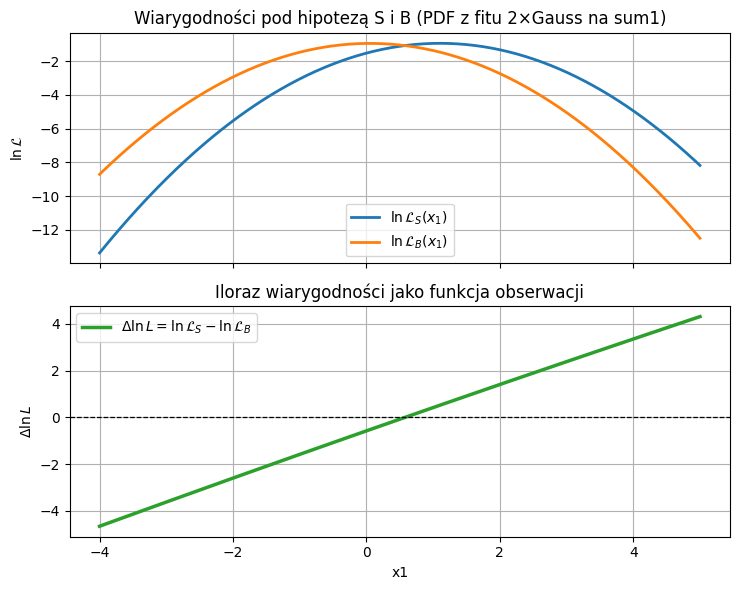

In [8]:
# Iloraz wiarygodności to FUNKCJA x1: Δln L(x1) = ln L_S(x1) - ln L_B(x1),
# przy L_k ∝ PDF rozkładu x1 pod hipotezą k. Parametry obu Gausów z fitu mieszaniny na sum1.
eps = 1e-12

xg = np.linspace(-4, 5, 500)
Ls_x = norm.pdf(xg, loc=mus_hat, scale=ss_hat)
Lb_x = norm.pdf(xg, loc=mub_hat, scale=sb_hat)
lnLs = np.log(Ls_x + eps)
lnLb = np.log(Lb_x + eps)
dll_x = lnLs - lnLb

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
axes[0].plot(xg, lnLs, lw=2, label=r"$\ln \mathcal{L}_S(x_1)$")
axes[0].plot(xg, lnLb, lw=2, label=r"$\ln \mathcal{L}_B(x_1)$")
axes[0].set_ylabel(r"$\ln \mathcal{L}$")
axes[0].set_title("Wiarygodności pod hipotezą S i B (PDF z fitu 2×Gauss na sum1)")
axes[0].legend(loc="lower center")

axes[1].plot(xg, dll_x, lw=2.5, color="C2", label=r"$\Delta\ln L = \ln\mathcal{L}_S - \ln\mathcal{L}_B$")
axes[1].axhline(0.0, color="k", lw=0.9, ls="--")
axes[1].set_xlabel("x1")
axes[1].set_ylabel(r"$\Delta\ln L$")
axes[1].set_title("Iloraz wiarygodności jako funkcja obserwacji")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

### Zmienna rozdzielająca a iloraz wiarygodności

**Zmienna rozdzielająca** (ang. *discriminating variable*, czasem *discriminant*) to taka **funkcja** przypisana każdemu zdarzeniu (jedna liczba na zdarzenie), że rozkłady tej liczby dla prawdziwego sygnału **S** i dla tła **B** można jak najlepiej **odsunąć** od siebie. Wtedy dowolny **próg** na tej zmiennej daje kontrolę nad kompromisem: więcej sygnału przy większym „przecieku” tła albo odwrotnie.

Ustalone są dwie hipotezy o rozkładzie obserwacji: gęstość \(p(x\mid S)\) i \(p(x\mid B)\). **Iloraz wiarygodności** to
\[
\Lambda(x) \;=\; \frac{p(x\mid S)}{p(x\mid B)}\,.
\]
Z logarytmu (wygodniejszy w obliczeniach, additive przy wielu cechach):
\[
\Delta\ln L(x) \;=\; \ln p(x\mid S) - \ln p(x\mid B) \;=\; \ln \Lambda(x)\,.
\]
To jest dokładnie krzywa z poprzedniej komórki, gdy za \(p(\cdot\mid S)\) i \(p(\cdot\mid B)\) bierzemy dopasowane Gaussy.

**Jak „zrobić” zmienną rozdzielającą z ilorazu (krok po kroku):**

1. **Wybierz modele** \(p(x\mid S)\) i \(p(x\mid B)\) — tu z fity mieszaniny na `sum1` masz parametry obu Gausów; możesz też użyć modeli z osobnych próbek oznakowanych (`model_S`, `model_B`).
2. **Dla każdego zdarzenia** o wartości \(x_1\) policz skor:  
   `score = ln L_S(x1) - ln L_B(x1)` (np. log PDF + małe `eps` pod log).
3. Ta liczba `score` **jest już** zmienną rozdzielającą. Kroki dalej w notebooku to wybór **progu** \(t\) (np. akceptuj jako S, jeśli `score > t`), macierz pomyłek i krzywa ROC — wszystko na tej samej skali co \(\Delta\ln L\).

**Uwaga:** przy wielu **niezależnych** cechach \(x = (x^{(1)},\ldots,x^{(d)})\) ten sam argument daje mnożenie ilorazów, czyli **sumę** \(\Delta\ln L\) z poszczególnych współrzędnych.

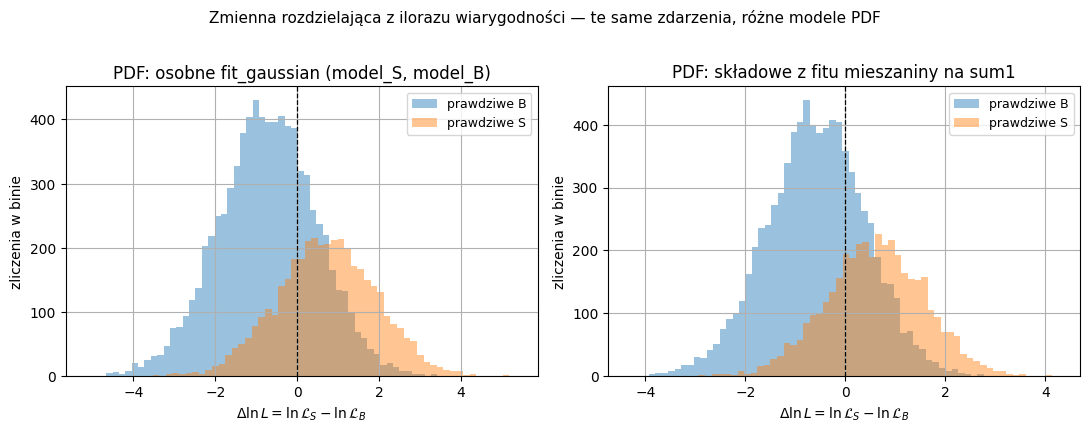

In [9]:
# Zmienna rozdzielająca: dla każdego zdarzenia score = Δln L(x₁) = ln L_S(x₁) − ln L_B(x₁).
# Histogramy poniżej to rozkłady tej liczby na prawdziwych próbkach S i B (nakładanie się → gorsza separacja).
eps = 1e-12

L_S = model_S.pdf(x1_S)
L_B = model_B.pdf(x1_S)
dll_S = np.log(L_S + eps) - np.log(L_B + eps)

L_Sb = model_S.pdf(x1_B)
L_Bb = model_B.pdf(x1_B)
dll_B = np.log(L_Sb + eps) - np.log(L_Bb + eps)

dll_S_mix = np.log(norm.pdf(x1_S, mus_hat, ss_hat) + eps) - np.log(
    norm.pdf(x1_S, mub_hat, sb_hat) + eps
)
dll_B_mix = np.log(norm.pdf(x1_B, mus_hat, ss_hat) + eps) - np.log(
    norm.pdf(x1_B, mub_hat, sb_hat) + eps
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for a, dS, dB, ttl in (
    (axes[0], dll_S, dll_B, "PDF: osobne fit_gaussian (model_S, model_B)"),
    (axes[1], dll_S_mix, dll_B_mix, "PDF: składowe z fitu mieszaniny na sum1"),
):
    a.hist(dB, bins=55, density=False, alpha=0.45, label="prawdziwe B")
    a.hist(dS, bins=55, density=False, alpha=0.45, label="prawdziwe S")
    a.axvline(0.0, color="k", lw=0.9, ls="--")
    a.set_xlabel(r"$\Delta\ln L = \ln\mathcal{L}_S - \ln\mathcal{L}_B$")
    a.set_ylabel("zliczenia w binie")
    a.set_title(ttl)
    a.legend(fontsize=9)
plt.suptitle(
    "Zmienna rozdzielająca z ilorazu wiarygodności — te same zdarzenia, różne modele PDF",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()
plt.show()


## 3) Macierz pomyłek, efficiency, purity, odrzut tła

Ustalamy próg na zmiennej ciągłej (tu: \(\Delta\ln\mathcal{L}\)).

- akceptujemy jako S, gdy \(\Delta\ln\mathcal{L} > t\)

Policzymy TP/FP/FN/TN oraz podstawowe miary.


In [10]:
scores = np.hstack([dll_S, dll_B])
labels = np.hstack([np.ones_like(dll_S, dtype=int), np.zeros_like(dll_B, dtype=int)])

def metrics_at_threshold(scores, labels, t):
    pred_S = (scores > t).astype(int)
    cm = confusion_matrix(labels, pred_S, labels=[1, 0])
    # cm = [[TP, FN], [FP, TN]] w tej kolejności etykiet
    TP, FN = cm[0, 0], cm[0, 1]
    FP, TN = cm[1, 0], cm[1, 1]
    eps_S = TP / (TP + FN) if (TP + FN) else np.nan
    eps_B = FP / (FP + TN) if (FP + TN) else np.nan
    purity = TP / (TP + FP) if (TP + FP) else np.nan
    rejection_B = (1.0 / eps_B) if (eps_B and eps_B > 0) else np.inf
    return dict(TP=TP, FP=FP, FN=FN, TN=TN, eps_S=eps_S, eps_B=eps_B, R_B=rejection_B, purity=purity)

for t in [-0.5, 0.0, 0.5, 1.0]:
    m = metrics_at_threshold(scores, labels, t)
    print(f"t={t:>4}: eps_S={m['eps_S']:.3f}  purity={m['purity']:.3f}  eps_B={m['eps_B']:.3f}  R_B={m['R_B']:.1f}")

t=-0.5: eps_S=0.846  purity=0.494  eps_B=0.433  R_B=2.3
t= 0.0: eps_S=0.729  purity=0.573  eps_B=0.272  R_B=3.7
t= 0.5: eps_S=0.572  purity=0.651  eps_B=0.153  R_B=6.5
t= 1.0: eps_S=0.411  purity=0.732  eps_B=0.075  R_B=13.3


## 4) ROC i AUC

Score ciągły pozwala przesuwać próg i oglądać kompromis \(\varepsilon_S\) vs \(\varepsilon_B\).

Wykres ROC rysujemy jako:
- oś X: \(\varepsilon_B\) (fałszywa akceptacja tła)
- oś Y: \(\varepsilon_S\) (wydajność sygnału)


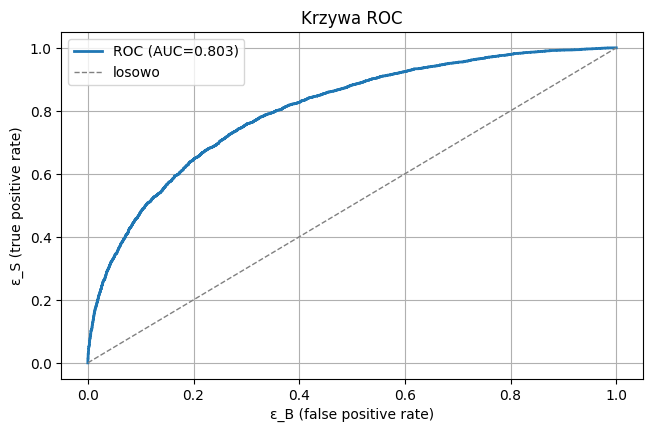

In [11]:
fpr, tpr, thr = roc_curve(labels, scores, pos_label=1)  # fpr=eps_B, tpr=eps_S
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="losowo")
plt.xlabel("ε_B (false positive rate)")
plt.ylabel("ε_S (true positive rate)")
plt.title("Krzywa ROC")
plt.legend()
plt.show()

## 5) Dobór progu pod cel analizy (w tym Asimov \(Z_A\))

Załóżmy, że interesuje nas „okno sygnałowe” po dalszych selekcjach (np. masa niezmiennicza), a PID ma zwiększyć istotność.

Dla każdego progu liczymy oczekiwane \(S\) i \(B\) po cięciu PID i porównujemy:
- orientacyjne \(S/\sqrt{S+B}\)
- Asimov \(Z_A\) (często używane w HEP):

\[
Z_A=\sqrt{2\left[(S+B)\ln\left(1+\frac{S}{B}\right)-S\right]}.
\]

Ważne: to są miary „na poziomie liczby zdarzeń”, nie pełna analiza z niepewnościami i dopasowaniem.


In [12]:
def Z_asimov(S, B):
    S = np.asarray(S, dtype=float)
    B = np.asarray(B, dtype=float)
    out = np.zeros_like(S)
    mask = B > 0
    out[mask] = np.sqrt(2.0 * ((S[mask] + B[mask]) * np.log(1.0 + S[mask] / B[mask]) - S[mask]))
    out[~mask] = np.nan
    return out

# Przyjmijmy "skalę" expected counts (np. po wszystkich innych selekcjach)
S0 = 500.0
B0 = 2000.0

thresholds = np.linspace(np.percentile(scores, 1), np.percentile(scores, 99), 120)

vals = []
for t in thresholds:
    m = metrics_at_threshold(scores, labels, t)
    S = S0 * m["eps_S"]
    B = B0 * m["eps_B"]
    Z_simple = S / np.sqrt(S + B) if (S + B) > 0 else np.nan
    ZA = float(Z_asimov(S, B))
    vals.append((t, m["eps_S"], m["eps_B"], m["purity"], Z_simple, ZA))

vals = np.array(vals, dtype=float)

t_best_simple = vals[np.nanargmax(vals[:, 4]), 0]
t_best_ZA = vals[np.nanargmax(vals[:, 5]), 0]

t_best_simple, t_best_ZA

(np.float64(-0.0782692270201375), np.float64(0.726255627218328))

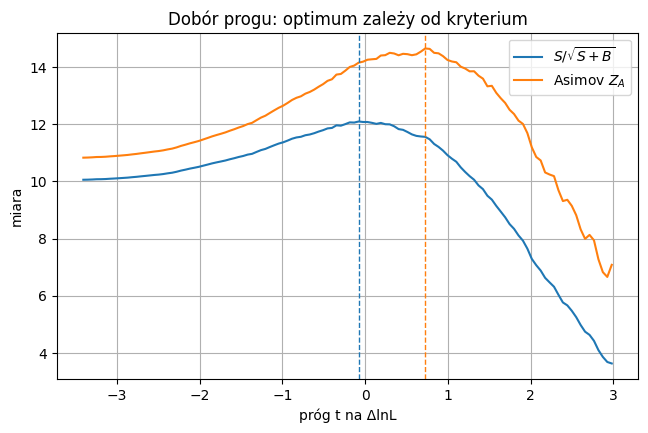

best simple: t=-0.078  eps_S=0.753  eps_B=0.297  purity=0.559  S=376.8 B=593.8  Zsimple=12.094  ZA=14.150
    best ZA: t=+0.726  eps_S=0.502  eps_B=0.111  purity=0.694  S=251.1 B=221.0  Zsimple=11.557  ZA=14.646


In [13]:
plt.plot(vals[:, 0], vals[:, 4], label=r"$S/\sqrt{S+B}$")
plt.plot(vals[:, 0], vals[:, 5], label=r"Asimov $Z_A$")
plt.axvline(t_best_simple, color="C0", ls="--", lw=1)
plt.axvline(t_best_ZA, color="C1", ls="--", lw=1)
plt.xlabel("próg t na ΔlnL")
plt.ylabel("miara")
plt.title("Dobór progu: optimum zależy od kryterium")
plt.legend()
plt.show()

for name, t in [("best simple", t_best_simple), ("best ZA", t_best_ZA)]:
    m = metrics_at_threshold(scores, labels, t)
    S = S0 * m["eps_S"]
    B = B0 * m["eps_B"]
    print(
        f"{name:>11}: t={t:+.3f}  eps_S={m['eps_S']:.3f}  eps_B={m['eps_B']:.3f}  purity={m['purity']:.3f}  "
        f"S={S:.1f} B={B:.1f}  Zsimple={S/np.sqrt(S+B):.3f}  ZA={float(Z_asimov(S,B)):.3f}"
    )

## 6) Niepewności systematyczne: przykład przesunięcia kalibracji

W tym punkcie pokazujemy prosty model **systematyki**: przesuwamy zmienną \(x_1\) o stałą wartość \(\delta\) (np. dryft kalibracji \(\dEdx\) lub TOF) i patrzymy, jak zmieniają się metryki przy stałym progu.

Bootstrap niepewności statystycznych zrobimy później na przykładzie **fitów masy niezmienniczej** (sekcja 7).


In [14]:
t0 = float(t_best_ZA)

m0 = metrics_at_threshold(scores, labels, t0)
print("Próg referencyjny t0=", t0)
print("purity(t0)=", m0["purity"], "eps_S=", m0["eps_S"], "eps_B=", m0["eps_B"])

# Prosta "systematyka": przesunięcie x1 o δ i przeliczenie scores

def dll_from_x1(x1):
    return np.log(model_S.pdf(x1) + eps) - np.log(model_B.pdf(x1) + eps)

for delta in [-0.15, 0.0, +0.15]:
    dll_S_shift = dll_from_x1(x1_S + delta)
    dll_B_shift = dll_from_x1(x1_B + delta)
    scores_shift = np.hstack([dll_S_shift, dll_B_shift])
    m = metrics_at_threshold(scores_shift, labels, t0)
    print(f"δ={delta:+.2f}: purity={m['purity']:.4f}  eps_S={m['eps_S']:.4f}  eps_B={m['eps_B']:.4f}")


Próg referencyjny t0= 0.726255627218328
purity(t0)= 0.6944348427238161 eps_S= 0.50225 eps_B= 0.1105
δ=-0.15: purity=0.7230  eps_S=0.4410  eps_B=0.0845
δ=+0.00: purity=0.6944  eps_S=0.5022  eps_B=0.1105
δ=+0.15: purity=0.6579  eps_S=0.5573  eps_B=0.1449


## 7) Masa niezmiennicza: pik + tło kombinatoryczne

Zrobimy zabawkowy przykład rozkładu masy niezmienniczej \(M\):
- sygnał: wąski pik (aproksymujemy Gauss),
- tło: gładkie (np. wykładnicze/polinom).

Następnie pokażemy 3 podejścia:
- **fit** sygnał+tło,
- **sideband** (obszary boczne),
- **mixed events** i **like-sign** jako modele tła (w prostym ujęciu).


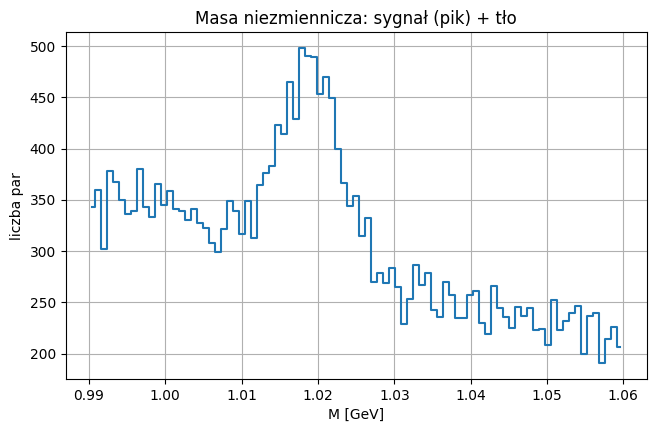

In [15]:
# Generujemy rozkład masy: sygnał + tło
m0_true = 1.019  # "phi(1020)" ~ 1.019 GeV, tu tylko jako liczba
sigma_true = 0.004

Nsig = 2500
Nbkg = 25000

m_sig = np.random.normal(loc=m0_true, scale=sigma_true, size=Nsig)

# tło: wykładnicze w pewnym zakresie (dla zabawki)
low, high = 0.99, 1.06
u = np.random.rand(Nbkg)
# inwersja CDF dla exp(-a m)
a = 8.0
Z = np.exp(-a*low) - np.exp(-a*high)
m_bkg = -1.0/a * np.log(np.exp(-a*low) - u*Z)

m = np.hstack([m_sig, m_bkg])

bins_m = np.linspace(low, high, 90)
counts, edges = np.histogram(m, bins=bins_m)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.step(centers, counts, where="mid")
plt.xlabel("M [GeV]")
plt.ylabel("liczba par")
plt.title("Masa niezmiennicza: sygnał (pik) + tło")
plt.show()

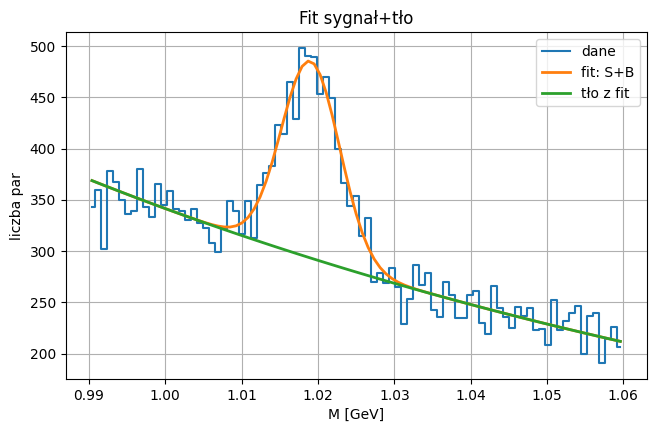

Fit:
mu = 1.019014 GeV
sigma = 0.003832 GeV
a (tło) = 7.995


In [16]:
def gauss(x, A, mu, sig):
    return A * np.exp(-0.5 * ((x - mu) / sig) ** 2)


def bkg_exp(x, B, a):
    return B * np.exp(-a * x)


def model_sig_bkg(x, A, mu, sig, B, a):
    return gauss(x, A, mu, sig) + bkg_exp(x, B, a)

# Fit w zakresie
mask_fit = (centers > 0.995) & (centers < 1.055)

p0 = [counts.max(), 1.019, 0.005, counts.min(), 5.0]
pars, cov = curve_fit(model_sig_bkg, centers[mask_fit], counts[mask_fit], p0=p0, maxfev=20000)
A_hat, mu_hat, sig_hat, B_hat, a_hat = pars

plt.step(centers, counts, where="mid", label="dane")
plt.plot(centers, model_sig_bkg(centers, *pars), lw=2, label="fit: S+B")
plt.plot(centers, bkg_exp(centers, B_hat, a_hat), lw=2, label="tło z fit")
plt.xlabel("M [GeV]")
plt.ylabel("liczba par")
plt.title("Fit sygnał+tło")
plt.legend()
plt.show()

print("Fit:")
print(f"mu = {mu_hat:.6f} GeV")
print(f"sigma = {sig_hat:.6f} GeV")
print(f"a (tło) = {a_hat:.3f}")

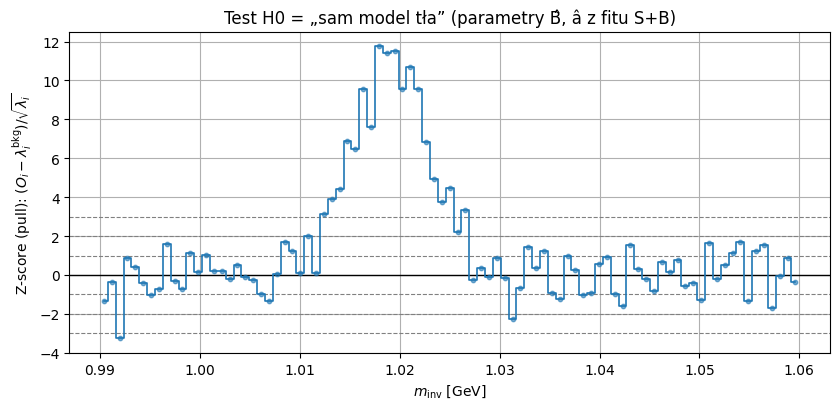

Okno piku (bins): O=11077,  λ_bkg=8751.5  →  Z ≈ 24.86 (nadwyżka względem H0 tylko-tło)


In [17]:
# Z-score (pull) przy H0: w każdym binie zliczenia ~ Poisson(λ_i), gdzie λ_i pochodzi TYLKO z dopasowanego tła (bez piku sygnałowego).
# Z_i = (O_i − λ_i) / √λ_i  — przy H0 i dużym λ rozkład Z_i ≈ N(0,1).
lambda_bkg = bkg_exp(centers, B_hat, a_hat)
Z_pull = (counts - lambda_bkg) / np.sqrt(np.clip(lambda_bkg, 1e-12, None))

fig, ax = plt.subplots(1, 1, figsize=(8.5, 4.2))
ax.axhline(0.0, color="k", lw=1.0)
for z in (1.0, 2.0, 3.0):
    ax.axhline(z, color="0.5", ls="--", lw=0.8)
    ax.axhline(-z, color="0.5", ls="--", lw=0.8)
ax.step(centers, Z_pull, where="mid", color="C0", lw=1.2)
ax.scatter(centers, Z_pull, s=10, alpha=0.6, c="C0", zorder=3)
ax.set_xlabel(r"$m_{\mathrm{inv}}$ [GeV]")
ax.set_ylabel(r"Z-score (pull): $(O_i-\lambda_i^{\mathrm{bkg}})/\sqrt{\lambda_i}$")
ax.set_title("Test H0 = „sam model tła” (parametry B̂, â z fitu S+B)")
plt.tight_layout()
plt.show()

# Orientacyjna istotność nadwyżki w oknie piku (jak w sekcji sideband — inna definicja B)
mask_peak = (centers > 1.008) & (centers < 1.032)
O_peak = counts[mask_peak].sum()
lam_peak = lambda_bkg[mask_peak].sum()
if lam_peak > 0:
    Z_excess = (O_peak - lam_peak) / np.sqrt(lam_peak)
    print(f"Okno piku (bins): O={O_peak:.0f},  λ_bkg={lam_peak:.1f}  →  Z ≈ {Z_excess:.2f} (nadwyżka względem H0 tylko-tło)")


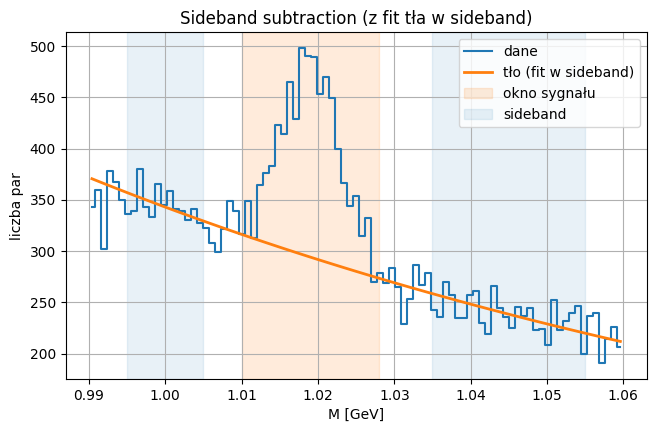

W oknie sygnału: N_obs=9063  B_est≈6788.0  S_est≈2275.0


In [18]:
# Sideband: estymacja tła z obszarów bocznych i interpolacja pod pik

signal_window = (1.010, 1.028)
sideband_left = (0.995, 1.005)
sideband_right = (1.035, 1.055)

mL, mR = signal_window

def in_range(x, a, b):
    return (x >= a) & (x <= b)

mask_sig = in_range(centers, *signal_window)
mask_sb = in_range(centers, *sideband_left) | in_range(centers, *sideband_right)

# Fit tylko tła w sideband (ta sama forma exp)
p0_b = [counts[mask_sb].max(), 5.0]
pars_b, cov_b = curve_fit(bkg_exp, centers[mask_sb], counts[mask_sb], p0=p0_b, maxfev=20000)
B2, a2 = pars_b

B_est = np.sum(bkg_exp(centers[mask_sig], B2, a2))
N_obs = np.sum(counts[mask_sig])
S_est = N_obs - B_est

plt.step(centers, counts, where="mid", label="dane")
plt.plot(centers, bkg_exp(centers, B2, a2), lw=2, label="tło (fit w sideband)")
plt.axvspan(*signal_window, color="C1", alpha=0.15, label="okno sygnału")
plt.axvspan(*sideband_left, color="C0", alpha=0.10, label="sideband")
plt.axvspan(*sideband_right, color="C0", alpha=0.10)
plt.xlabel("M [GeV]")
plt.ylabel("liczba par")
plt.title("Sideband subtraction (z fit tła w sideband)")
plt.legend(loc="upper right")
plt.show()

print(f"W oknie sygnału: N_obs={N_obs:.0f}  B_est≈{B_est:.1f}  S_est≈{S_est:.1f}")

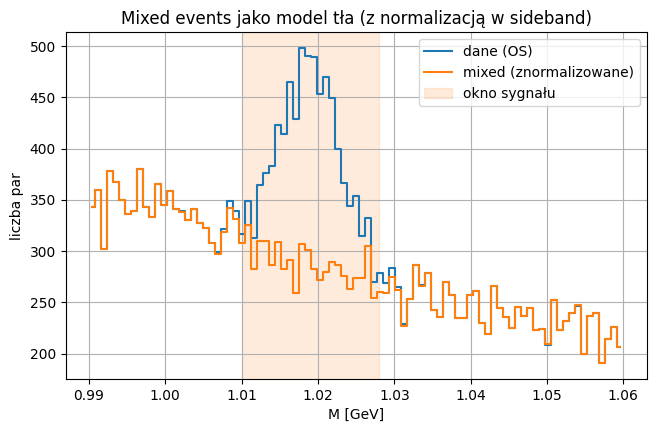

S_est (mixed) ≈ 2434.4


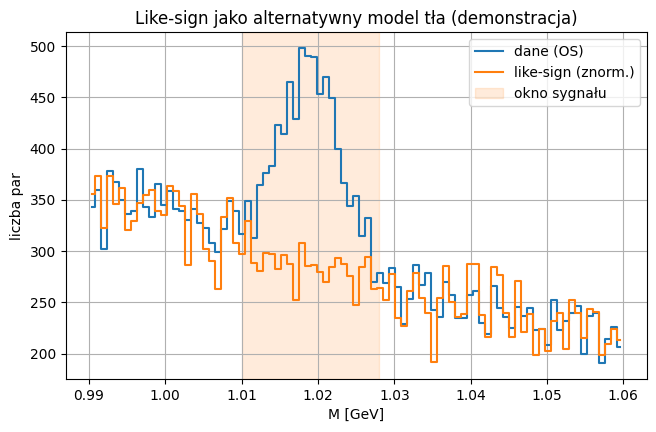

S_est (like-sign) ≈ 2492.9


In [19]:
# Mixed events / like-sign: zabawkowe "szablony" tła
# W realnych analizach to osobne histogramy; tu zrobimy prostą demonstrację idei.

# Załóżmy, że "mixed" dobrze opisuje kształt tła, ale wymaga normalizacji.
# Skonstruujemy mixed jako histogram z samych m_bkg (tu: znamy prawdę w zabawce).

counts_mix, _ = np.histogram(m_bkg, bins=bins_m)

# Normalizacja mixed do danych w sideband
scale = counts[mask_sb].sum() / (counts_mix[mask_sb].sum() + 1e-12)
counts_mix_scaled = counts_mix * scale

plt.step(centers, counts, where="mid", label="dane (OS)")
plt.step(centers, counts_mix_scaled, where="mid", label="mixed (znormalizowane)")
plt.axvspan(*signal_window, color="C1", alpha=0.15, label="okno sygnału")
plt.xlabel("M [GeV]")
plt.ylabel("liczba par")
plt.title("Mixed events jako model tła (z normalizacją w sideband)")
plt.legend()
plt.show()

S_est_mix = counts[mask_sig].sum() - counts_mix_scaled[mask_sig].sum()
print(f"S_est (mixed) ≈ {S_est_mix:.1f}")

# Like-sign: w zabawce potraktujmy to jako alternatywny szablon tła (z fluktuacją)
counts_ls = np.random.poisson(lam=counts_mix)  # tylko, żeby było "inne"
scale_ls = counts[mask_sb].sum() / (counts_ls[mask_sb].sum() + 1e-12)
counts_ls_scaled = counts_ls * scale_ls

plt.step(centers, counts, where="mid", label="dane (OS)")
plt.step(centers, counts_ls_scaled, where="mid", label="like-sign (znorm.)")
plt.axvspan(*signal_window, color="C1", alpha=0.15, label="okno sygnału")
plt.xlabel("M [GeV]")
plt.ylabel("liczba par")
plt.title("Like-sign jako alternatywny model tła (demonstracja)")
plt.legend()
plt.show()

S_est_ls = counts[mask_sig].sum() - counts_ls_scaled[mask_sig].sum()
print(f"S_est (like-sign) ≈ {S_est_ls:.1f}")

## 8) Bootstrap niepewności statystycznych dla fitu masy niezmienniczej (multinomial)

Teraz robimy bootstrap „po eventach” dla przykładu masy niezmienniczej.

- Traktujemy listę zrekonstruowanych par (eventów) jako nasz zbiór danych: wartości masy \(M\).
- Dla każdej próby bootstrapowej losujemy **ile razy każdy event ma się powtórzyć**.
  Zrobimy to przez losowanie z rozkładu **multinomialnego**: 
  \(\mathbf{n}\sim\mathrm{Multinomial}(N, \mathbf{p})\) z \(p_i=1/N\).
- Dla każdej próbki budujemy histogram (z wagami \(n_i\)) i dopasowujemy model \(S+B\).

Z rozkładów wyników z 100 próbek BS wyznaczymy niepewności statystyczne parametrów sygnału:
- \(N\) (yield sygnału – tutaj w przybliżeniu z parametrów Gaussa),
- \(\mu\), \(\sigma\).


Wykonano 100/100 dopasowań bootstrap.
N (yield)  : 2359.80 ± 121.96  (stat, BS)
mu [GeV]   : 1.018987 ± 0.000225  (stat, BS)
sigma [GeV]: 0.003829 ± 0.000192  (stat, BS)


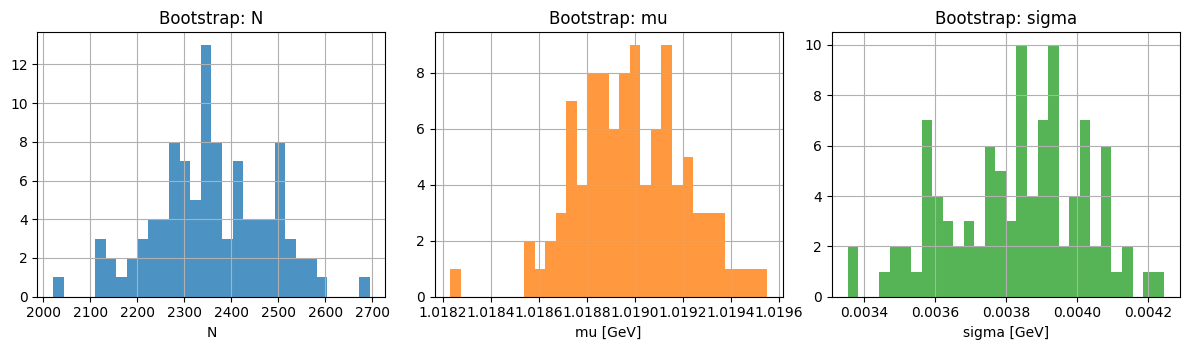

In [20]:
# Bootstrap: 100 próbek przez multinomialne powtórzenia eventów

m_events = m.copy()  # lista "eventów" (mas par)
N_events = len(m_events)

# Ustalenia histogramu (jak wcześniej)
bins_bs = bins_m
centers_bs = centers
bin_width = float(bins_bs[1] - bins_bs[0])

# Użyjmy parametrów z dopasowania na pełnych danych jako start (jeśli istnieją)
try:
    p0_bs = pars
except NameError:
    p0_bs = [counts.max(), 1.019, 0.005, counts.min(), 5.0]

# Multinomial z p_i=1/N jest równoważny bootstrapowi z powtórzeniami,
# ale od razu daje nam liczności powtórzeń każdego eventu.
p_equal = np.full(N_events, 1.0 / N_events)

A_list = []
mu_list = []
sig_list = []
N_list = []

n_boot = 100

for b in range(n_boot):
    mult_counts = np.random.multinomial(N_events, p_equal)

    # Histogram z wagami (ile razy event został wylosowany)
    counts_bs, _ = np.histogram(m_events, bins=bins_bs, weights=mult_counts)

    # Dopasowanie S+B do zliczeń (jak wcześniej)
    # Prosta waga ~ Poisson: sigma ~ sqrt(N+1) (stabilizacja dla zer)
    sigma_y = np.sqrt(counts_bs + 1.0)

    try:
        pars_b, cov_b = curve_fit(
            model_sig_bkg,
            centers_bs[mask_fit],
            counts_bs[mask_fit],
            p0=p0_bs,
            sigma=sigma_y[mask_fit],
            absolute_sigma=True,
            maxfev=20000,
        )
    except RuntimeError:
        # Jeśli pojedynczy fit się wysypie, pomijamy próbkę
        continue

    A_hat, mu_hat, sig_hat, B_hat, a_hat = pars_b

    # Przybliżony yield sygnału z parametrów Gaussa.
    # Uwaga: w naszym prostym modelu A jest "wysokością piku" w zliczeniach.
    # Przybliżamy N jako całkę po gaussie podzieloną przez szerokość binu.
    N_hat = (A_hat * abs(sig_hat) * np.sqrt(2.0 * np.pi)) / bin_width

    A_list.append(A_hat)
    mu_list.append(mu_hat)
    sig_list.append(abs(sig_hat))
    N_list.append(N_hat)

    # aktualizuj p0, żeby kolejne dopasowania były stabilniejsze
    p0_bs = pars_b

A_arr = np.asarray(A_list)
mu_arr = np.asarray(mu_list)
sig_arr = np.asarray(sig_list)
N_arr = np.asarray(N_list)

print(f"Wykonano {len(N_arr)}/{n_boot} dopasowań bootstrap.")
print(f"N (yield)  : {N_arr.mean():.2f} ± {N_arr.std(ddof=1):.2f}  (stat, BS)")
print(f"mu [GeV]   : {mu_arr.mean():.6f} ± {mu_arr.std(ddof=1):.6f}  (stat, BS)")
print(f"sigma [GeV]: {sig_arr.mean():.6f} ± {sig_arr.std(ddof=1):.6f}  (stat, BS)")

# Podgląd rozkładów bootstrap
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].hist(N_arr, bins=30, color="C0", alpha=0.8)
axes[0].set_title("Bootstrap: N")
axes[0].set_xlabel("N")

axes[1].hist(mu_arr, bins=30, color="C1", alpha=0.8)
axes[1].set_title("Bootstrap: mu")
axes[1].set_xlabel("mu [GeV]")

axes[2].hist(sig_arr, bins=30, color="C2", alpha=0.8)
axes[2].set_title("Bootstrap: sigma")
axes[2].set_xlabel("sigma [GeV]")

plt.tight_layout()
plt.show()